**Importing Libraries**

In [4]:
from preprocess import get_data_generator_rgb
from keras._tf_keras.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, Input, GlobalAveragePooling2D
from keras._tf_keras.keras.callbacks import EarlyStopping, ModelCheckpoint
from keras._tf_keras.keras.models import load_model, Model
import matplotlib.pyplot as plt
import json
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import seaborn as sns
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.scores import CategoricalScore
import cv2
import os
from random import choice
import pandas as pd

**Load and Prepare Dataset**

In [2]:
train_dir = 'fer2013/train'
test_dir = 'fer2013/test'
img_size = (48, 48)
batch_size = 32
num_classes = 7
# Load data using your custom preprocess
train_gen, val_gen, test_gen = get_data_generator_rgb(train_dir, test_dir, img_size=img_size, batch_size=batch_size)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


**Implement CNN Baseline Architecture**

In [ ]:
# Input layer
inputs = Input(shape=(48, 48, 3))

# Block 1
x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

# Block 2
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.3)(x)

# Block 3
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.4)(x)

# Block 4
x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(256, (3, 3), activation='relu', padding='same', name='last_conv')(x)  # Named for Grad-CAM
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

# Global Average Pooling
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

# Output layer
outputs = Dense(train_gen.num_classes, activation='softmax')(x)

# Create model
model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,311,271 (5.00 MB)

 Trainable params: 1,309,351 (4.99 MB)

 Non-trainable params: 1,920 (7.50 KB)

**Set Optimizer, Train Model and Plot Training Result**

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 91s 82ms/step - accuracy: 0.2204 - loss: 1.9103 - val_accuracy: 0.3329 - val_loss: 1.7689
Epoch 2/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.3615 - loss: 1.6099 - val_accuracy: 0.3348 - val_loss: 1.7434
Epoch 3/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 49s 68ms/step - accuracy: 0.4428 - loss: 1.4464 - val_accuracy: 0.4767 - val_loss: 1.3761
Epoch 4/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.4725 - loss: 1.3629 - val_accuracy: 0.3717 - val_loss: 1.6850
Epoch 5/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 48s 67ms/step - accuracy: 0.5095 - loss: 1.2906 - val_accuracy: 0.4837 - val_loss: 1.3324
Epoch 6/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.5184 - loss: 1.2696 - val_accuracy: 0.5325 - val_loss: 1.2330
Epoch 7/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 48s 67ms/step - accuracy: 0.5317 - loss: 1.2396 - val_accuracy: 0.5551 - val_loss: 1.1782
Epoch 8/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.5429 - loss: 1

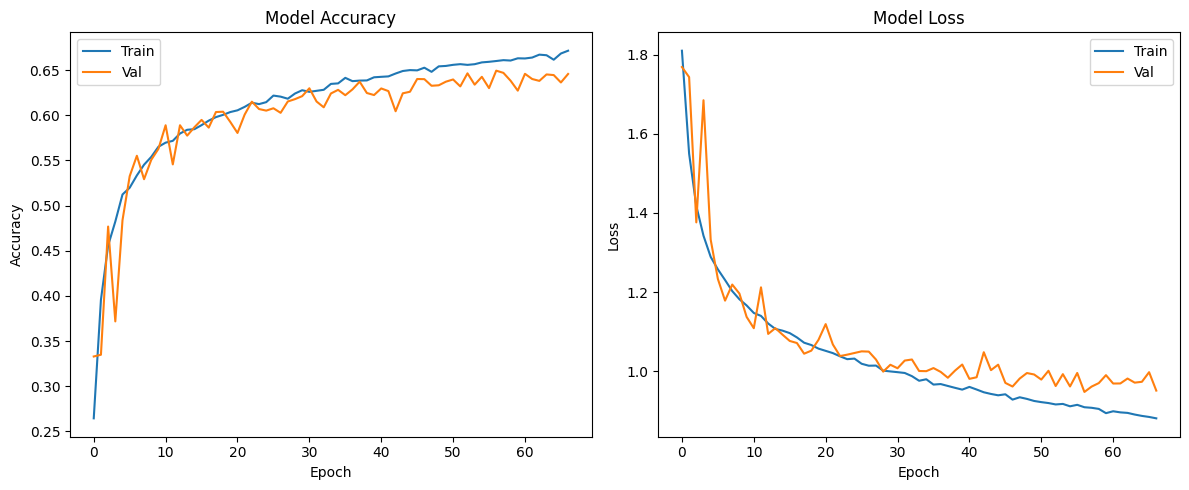

In [ ]:
# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
checkpoint = ModelCheckpoint('CNN_best.keras', save_best_only=True, monitor='val_accuracy', mode='max')
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model
history = model.fit(train_gen, validation_data=val_gen, epochs=100, callbacks=[checkpoint, early_stop])

# Save training history
with open('history_rgb.json', 'w') as f:
    json.dump(history.history, f)

# Evaluate
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.2f}")

test_results = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc)
}

with open('test_results_rgb.json', 'w') as f:
    json.dump(test_results, f)

# Plot training history
def plot_history(history):
    plt.figure(figsize=(12, 5))  # Create a figure with two subplots

    # Accuracy subplot (left)
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, position 1
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss subplot (right)
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, position 2
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()  # Prevent overlapping labels
    plt.show()

plot_history(history)

**Classification Report**

In [3]:
# Load saved model
model = load_model('models/CNN_best.keras')

# Predict on test data
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Full classification report
target_names = list(test_gen.class_indices.keys())
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))


C:\Users\User\AppData\Roaming\Python\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


225/225 ━━━━━━━━━━━━━━━━━━━━ 120s 513ms/step

Detailed Classification Report:
              precision    recall  f1-score   support

       angry       0.55      0.68      0.61       958
     disgust       0.83      0.36      0.50       111
        fear       0.56      0.38      0.45      1024
       happy       0.90      0.85      0.87      1774
     neutral       0.52      0.78      0.62      1233
         sad       0.62      0.39      0.48      1247
    surprise       0.74      0.82      0.78       831

    accuracy                           0.66      7178
   macro avg       0.67      0.61      0.62      7178
weighted avg       0.67      0.66      0.65      7178



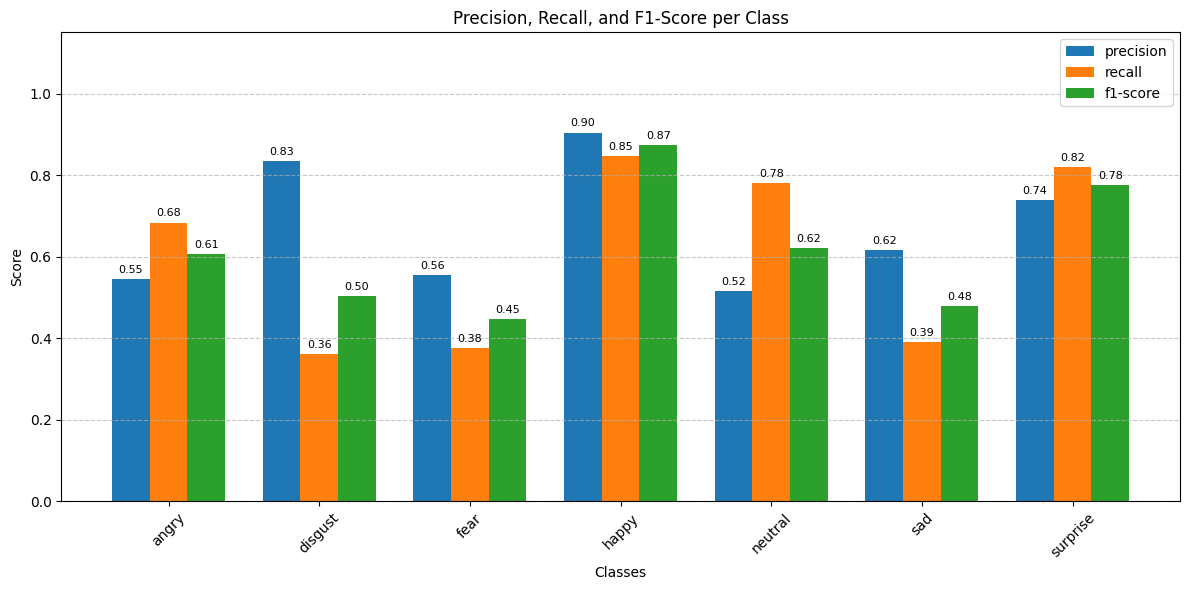

In [9]:
report_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)

df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.iloc[:-3]  # Remove 'accuracy', 'macro avg', 'weighted avg'
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(df_report))  # class indices
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, df_report[metric], width, label=metric)

# Add metric values above bars
for i, metric in enumerate(metrics):
    for j, val in enumerate(df_report[metric]):
        ax.text(j + i * width, val + 0.01, f"{val:.2f}", ha='center', va='bottom', fontsize=8)

# Formatting
ax.set_xlabel('Classes')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1-Score per Class')
ax.set_xticks(x + width)
ax.set_xticklabels(df_report.index, rotation=45)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Confusion Matrix**

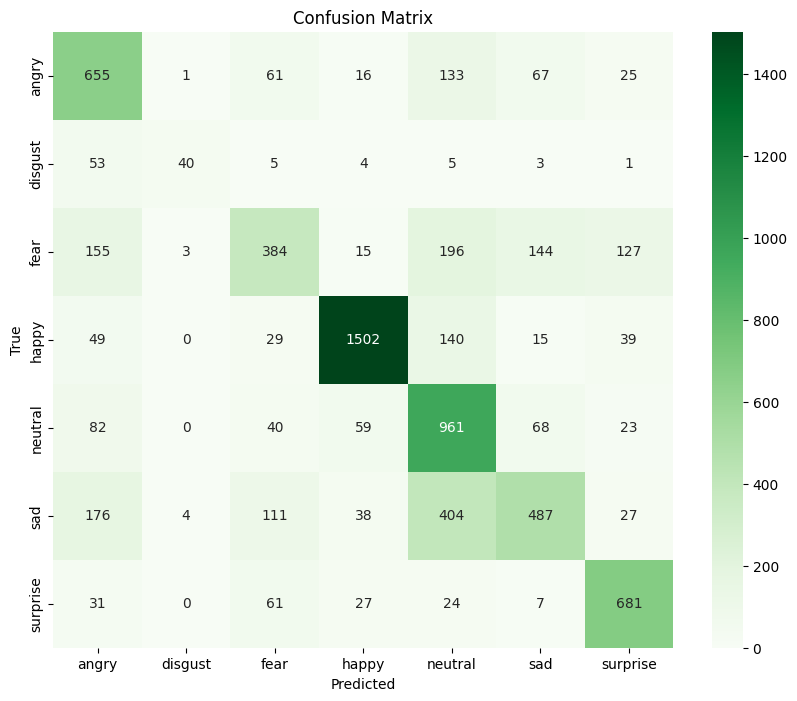

In [13]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

**ROC Curve**

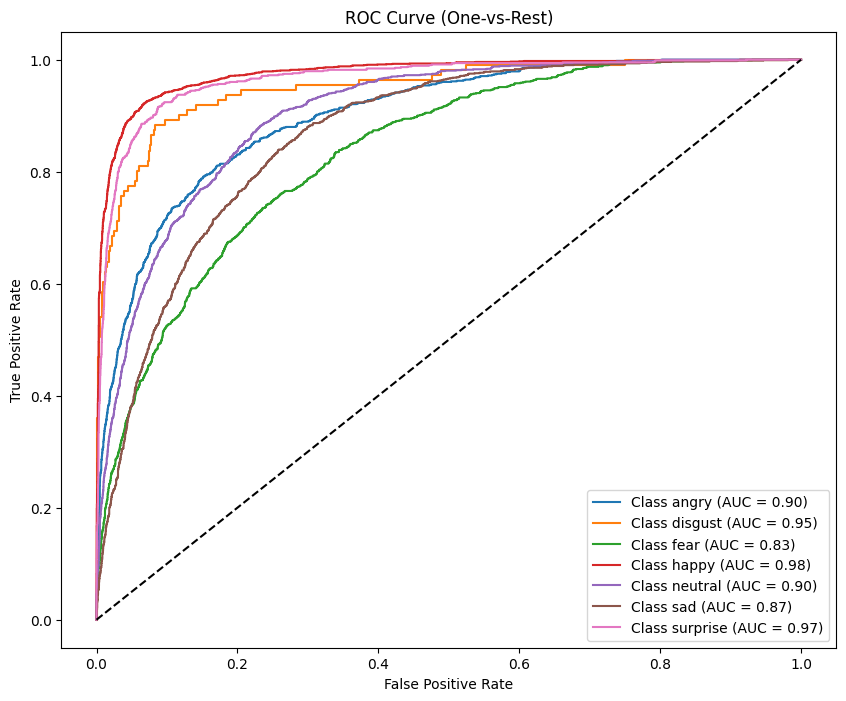

In [14]:
# Binarize the labels
n_classes = len(target_names)
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.show()

**Grad-CAM**

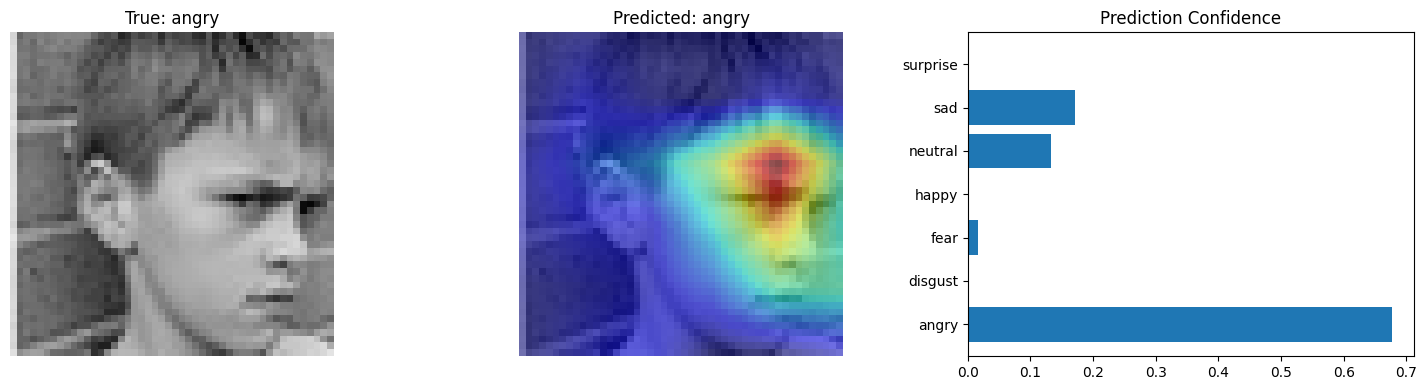

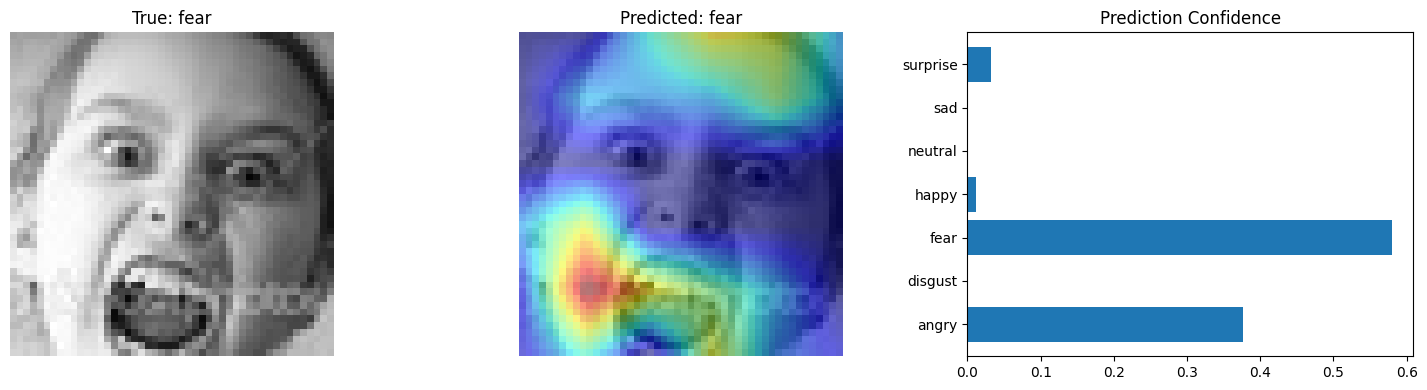

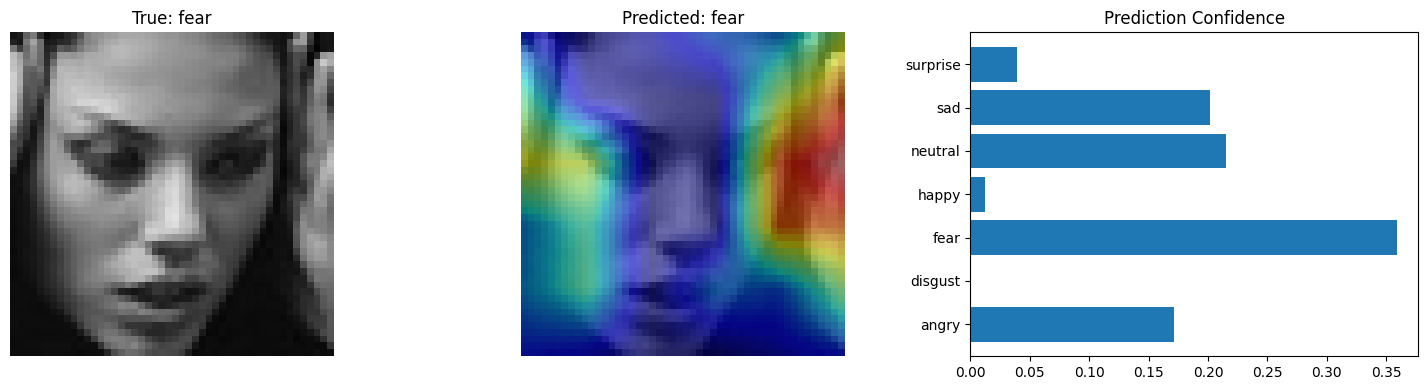

In [17]:
def load_random_image(test_dir, class_names, target_size=(48, 48)):
    emotion = choice(class_names)
    emotion_dir = os.path.join(test_dir, emotion)
    img_name = choice([f for f in os.listdir(emotion_dir) if f.endswith(('.jpg', '.png'))])
    img_path = os.path.join(emotion_dir, img_name)

    # Read, preprocess
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img.astype('float32') / 255.0
    return np.expand_dims(img, axis=0), class_names.index(emotion), img_path

# Grad-CAM Visualization
def run_gradcam(model, test_dir, class_names, num_samples=3, penultimate_layer_idx='last_conv'):
    gradcam = Gradcam(model)

    for _ in range(num_samples):
        img, true_class, path = load_random_image(test_dir, class_names)
        score = CategoricalScore([np.argmax(model.predict(img, verbose=0)[0])])

        cam = gradcam(score, img, penultimate_layer=penultimate_layer_idx)
        cam = np.maximum(cam, 0)
        cam = cam / (cam.max() + 1e-8)

        # Plot original + CAM overlay + confidence
        pred_probs = model.predict(img, verbose=0)[0]
        pred_class = np.argmax(pred_probs)

        plt.figure(figsize=(15, 4))

        # Original
        plt.subplot(1, 3, 1)
        plt.imshow(img[0])
        plt.title(f"True: {class_names[true_class]}")
        plt.axis('off')

        # Grad-CAM heatmap overlay
        plt.subplot(1, 3, 2)
        plt.imshow(img[0])
        plt.imshow(cam[0], cmap='jet', alpha=0.5)
        plt.title(f"Predicted: {class_names[pred_class]}")
        plt.axis('off')

        # Prediction Confidence
        plt.subplot(1, 3, 3)
        plt.barh(class_names, pred_probs)
        plt.title("Prediction Confidence")
        plt.tight_layout()
        plt.show()

# Usage
run_gradcam(model, test_dir, class_names=target_names, num_samples=3)

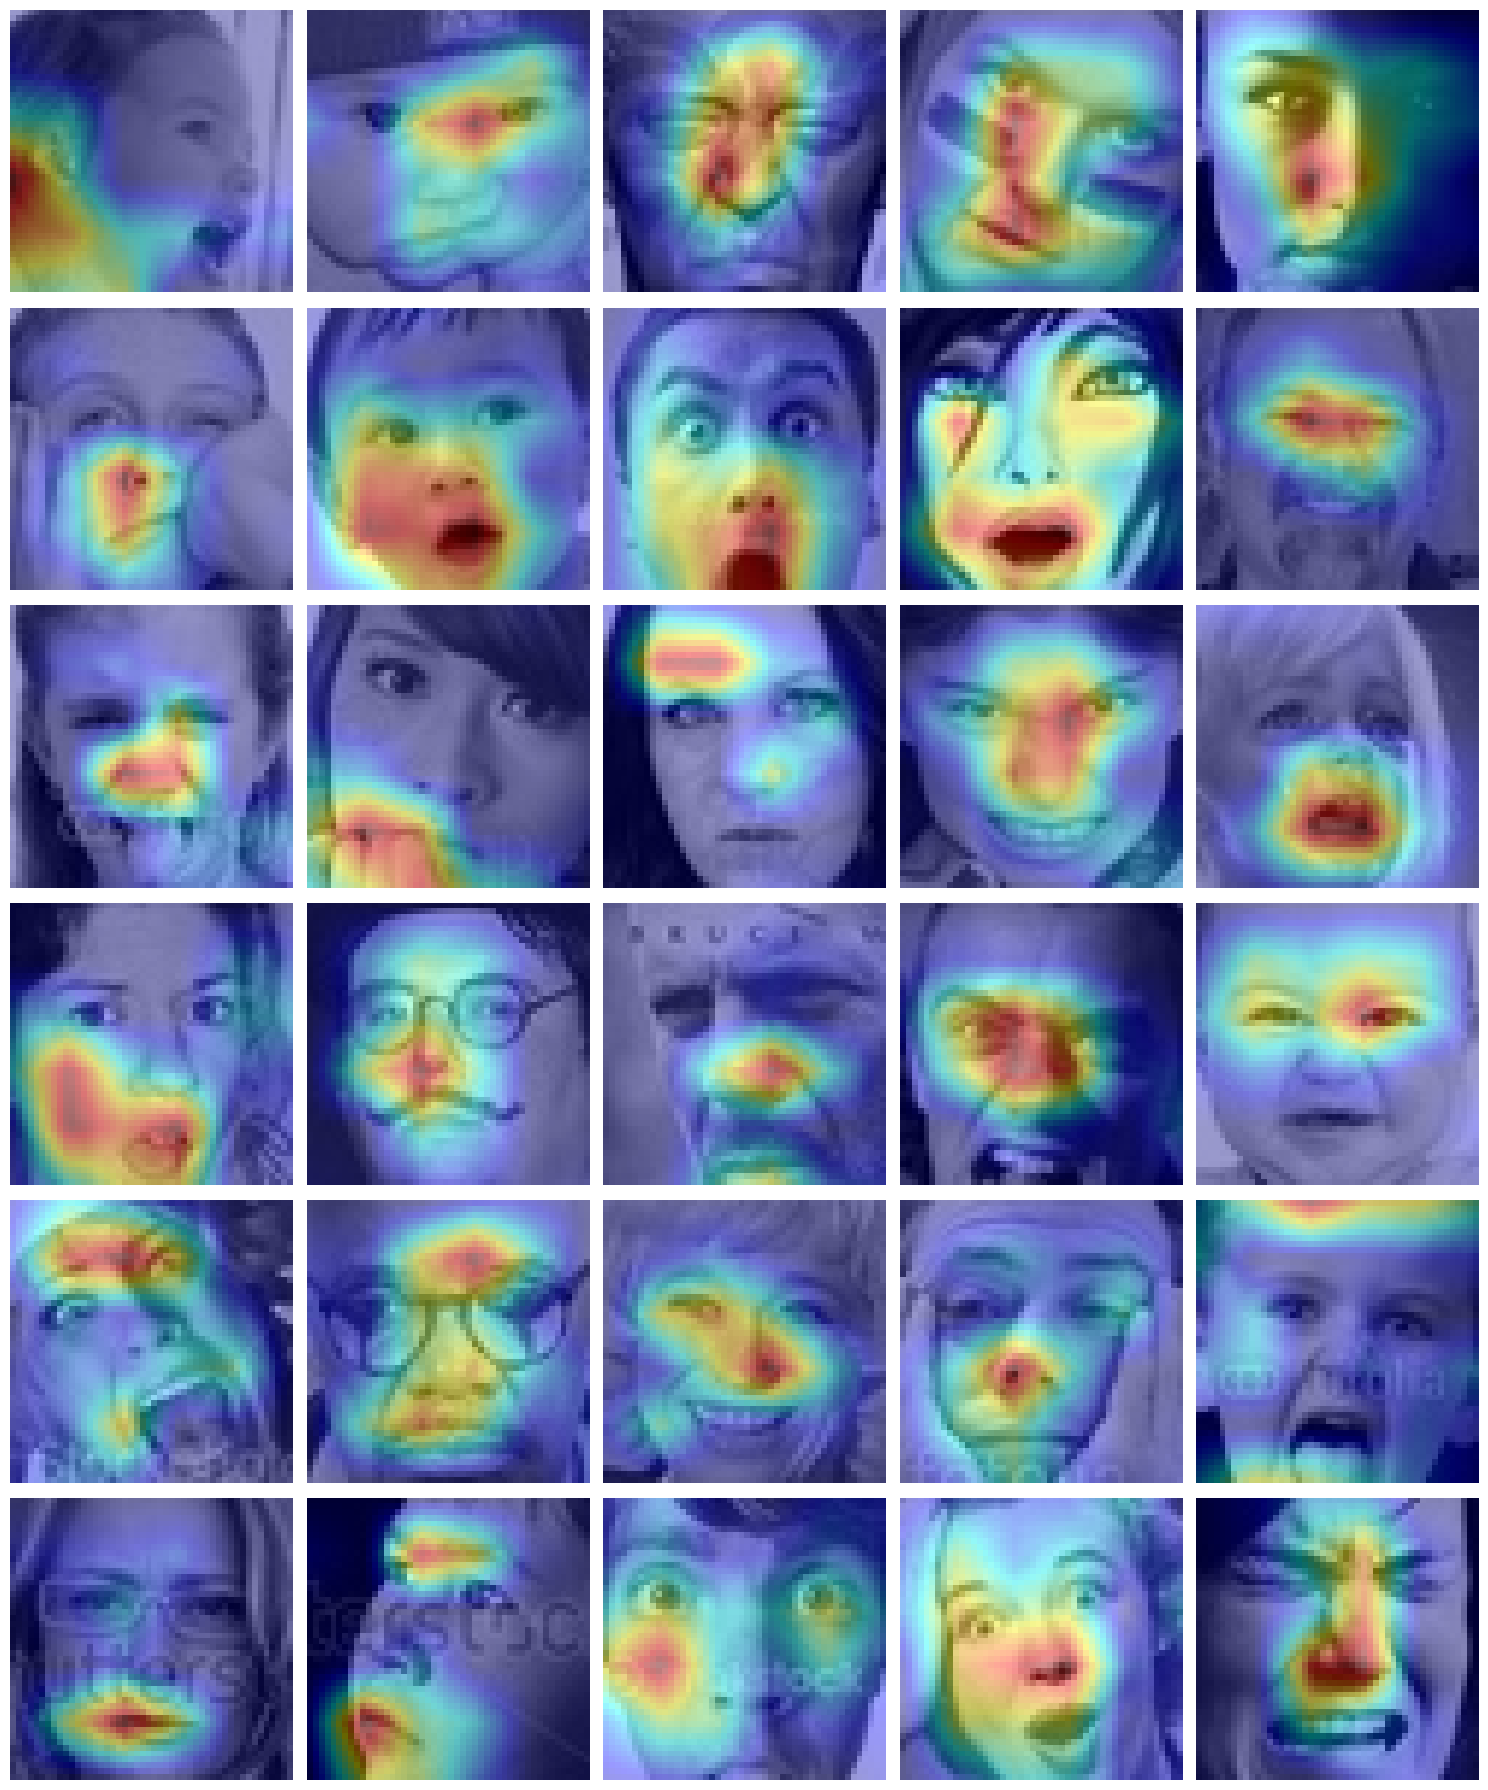

In [6]:
# Load and preprocess a random image from test_dir
def load_random_image(test_dir, class_names, target_size=(48, 48)):
    emotion = choice(class_names)
    emotion_dir = os.path.join(test_dir, emotion)
    img_name = choice([f for f in os.listdir(emotion_dir) if f.endswith(('.jpg', '.png'))])
    img_path = os.path.join(emotion_dir, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img.astype('float32') / 255.0
    return np.expand_dims(img, axis=0), class_names.index(emotion), img_path

# Grad-CAM visualization for multiple random images
def run_gradcam_grid(model, test_dir, class_names, num_images=30, penultimate_layer_idx='last_conv'):
    gradcam = Gradcam(model)

    n_cols = 5
    n_rows = int(np.ceil(num_images / n_cols))
    plt.figure(figsize=(n_cols * 3, n_rows * 3))

    for i in range(num_images):
        img, true_class, path = load_random_image(test_dir, class_names)
        pred = model.predict(img, verbose=0)[0]
        pred_class = np.argmax(pred)
        score = CategoricalScore([pred_class])

        cam = gradcam(score, img, penultimate_layer=penultimate_layer_idx)
        cam = np.maximum(cam, 0)
        cam = cam / (cam.max() + 1e-8)

        # Grad-CAM heatmap overlay only
        heatmap = cam[0]
        overlay = np.uint8(255 * heatmap)
        overlay = cv2.applyColorMap(overlay, cv2.COLORMAP_JET)
        overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

        img_rgb = np.uint8(255 * img[0])
        combined = cv2.addWeighted(img_rgb, 0.6, overlay, 0.4, 0)

        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(combined)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Usage
run_gradcam_grid(model, test_dir, class_names=target_names, num_images=30)